In [1]:
import numpy as np
import os
import pandas as pd
import h5py
import matplotlib.pyplot as plt
try:
    from few.trajectory.geodesic import get_separatrix
except ImportError:
    from few.utils.geodesic import get_separatrix

from few.utils.mappings.kerrecceq import (AMAX_nex,apex_of_uwyz_nex, z_of_a_nex, a_of_z_nex,u_of_p_flux_nex, 
                _kerrecceq_flux_forward_map_nex, u_of_p_flux_nex,p_of_u_flux_nex,DELTAPMAX_REGIONC,DELTAPMIN_REGIONC)

from multispline.spline import BicubicSpline, TricubicSpline
import matplotlib.colorizer as mcolorizer
import matplotlib.colors as mcolors


In [2]:
data_in = np.loadtxt('data/rectilinear_subset_v4.txt')
columns = ["a", "p", "e", "x", "pos", "Edot_tot", "Ldot_tot", "Qdot_tot", "Edot_hor", "Edot_inf", "Ldot_hor", "Ldot_inf", "Qdot_hor", "Qdot_inf", "timing (s)", "iu", "iw", "iz","u","w","y","z"]
df = pd.DataFrame(data_in, columns=columns)

In [3]:
np.unique(df["p"])

array([ 1.02387249,  1.02412822,  1.02479624, ..., 11.68523524,
       11.7330512 , 11.78218524], shape=(1215,))

In [4]:
with pd.option_context('display.max_rows', None,
    'display.max_columns', 22,
    'display.width', 13000,
    'display.precision', 10):
        print(df)

                 a              p     e    x     pos      Edot_tot      Ldot_tot          Qdot_tot      Edot_hor      Edot_inf      Ldot_hor      Ldot_inf          Qdot_hor          Qdot_inf        timing (s)    iu    iw    iz       u     w    y      z
0     0.9900000000   1.4782116751  0.00  1.0   756.0  0.0890756626  0.2482748318  0.0000000000e+00 -0.0084396520  0.0975153146 -0.0235232961  0.2717981279  0.0000000000e+00  0.0000000000e+00      0.0000000000   4.0   0.0   0.0 -1.6250  0.00  1.0  -2.00
1     0.9994376587   1.1703051822  0.00  1.0   730.0  0.0792126770  0.1794548421  0.0000000000e+00 -0.0106585184  0.0898711954 -0.0241466746  0.2036015167  0.0000000000e+00  0.0000000000e+00      0.0000000000   4.0   0.0   4.0 -1.6250  0.00  1.0  -3.25
2     0.9999683772   1.0761466696  0.00  1.0   776.0  0.0487213722  0.1031107897  0.0000000000e+00 -0.0072828706  0.0560042427 -0.0154130005  0.1185237903  0.0000000000e+00  0.0000000000e+00      0.0000000000   4.0   0.0   8.0 -1.6250  0.00 

In [6]:
1.4782116751- get_separatrix(0.99,0,1) , 10**(-1.625)

(0.02371373704032842, 0.023713737056616554)

In [7]:
data_loc = "rectilinear_subset_v4.txt"

with h5py.File('KerrEccEqFluxData_nex_v2.h5', 'w') as outfile:
    # region A
  #  dataA = pd.read_feather(os.path.join(data_loc))
   # df_infoA = pd.read_feather(os.path.join(data_loc, 'flux_grid_params_inner.feather'))
    dataA = df

    NU = 15
    NW = 9
    NZ = 9

    regionA = outfile.create_group('regionA')
    regionA.create_dataset('Edot', data=dataA["Edot_tot"].to_numpy().reshape(NU, NW, NZ)[:,:,:])
    regionA.create_dataset('Ldot', data=dataA["Ldot_tot"].to_numpy().reshape(NU, NW, NZ)[:,:,:])

    regionA.attrs['NU'] = NU
    regionA.attrs['NW'] = NW
    regionA.attrs['NZ'] = NZ

In [8]:
fp = "KerrEccEqFluxData_nex_v2.h5"  #Will change filename


file_path = fp

with h5py.File(file_path, "r") as fluxData:
    regionA = fluxData["regionA"]
    u = np.linspace(0, 1, regionA.attrs["NU"])
    w = np.linspace(0, 1, regionA.attrs["NW"])
    z = np.linspace(0, 1, regionA.attrs["NZ"])

    ugrid, wgrid, zgrid = np.asarray(
        np.meshgrid(u, w, z, indexing="ij")
    ).reshape(3, -1)
    agrid, pgrid, egrid, xgrid = apex_of_uwyz_nex(
        ugrid, wgrid, np.ones_like(zgrid), zgrid
    )

    # normalise by PN contribution
    Edot = regionA["Edot"][()]
    Ldot = regionA["Ldot"][()]
    


    Edot_interp_A = TricubicSpline(u, w, z, Edot)
    Ldot_interp_A = TricubicSpline(u, w, z, Ldot)

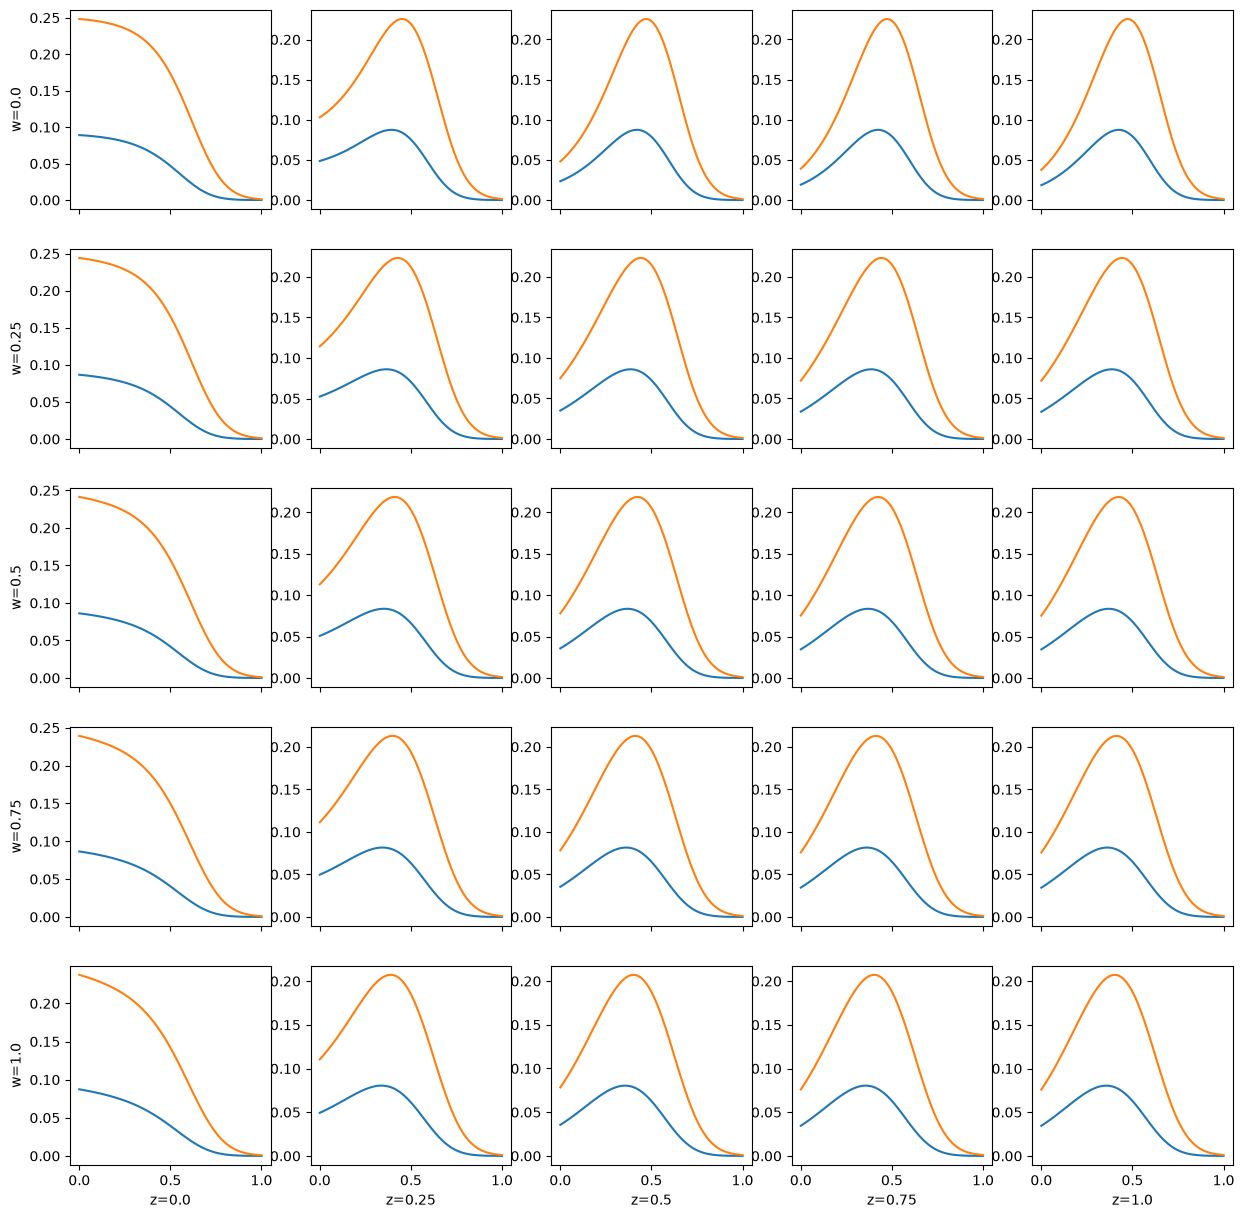

In [9]:
new_ugrid = np.linspace(0,1,100)
nz=5
nw=5

w_vals = np.linspace(0,1,nw)#[0,0.5,0.7,0.9]
z_vals = np.linspace(0,1,nz) #[0,0.2,0.5,0.7,0.8,0.87,0.875,0.9,0.99]


fig,axs = plt.subplots(len(w_vals),len(z_vals),figsize = (3*len(z_vals),3*len(w_vals)),sharex=True,sharey=False)


for i in range(len(w_vals)):
    for j in range(len(z_vals)):

        z = z_vals[j]
        w = w_vals[i]

        axs[i,j].plot(new_ugrid,Edot_interp_A(new_ugrid,w,z),label = r"$\dot{E}$")
        axs[i,j].plot(new_ugrid,Ldot_interp_A(new_ugrid,w,z),label = r"$\dot{L}$")

        if i == len(w_vals) -1 :
            axs[i,j].set_xlabel(f"z={z}")
        if j == 0 :
            axs[i,j].set_ylabel(f"w={w}")

#axs[0].set_xlabel("u")
#axs[0].set_ylabel(r"$\dot{E}$")

#axs[1].set_xlabel("u")
#axs[1].set_ylabel(r"$\dot{L}$")

In [6]:
timing_arr = np.asarray(df["timing (s)"]).reshape(15,9,9)  # NU NW NZ
p_arr = np.asarray(df["p"]).reshape(15,9,9)
e_arr = np.asarray(df["e"]).reshape(15,9,9)
a_arr = np.asarray(df["a"]).reshape(15,9,9)

In [7]:
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix"
})

plt.rcParams["text.usetex"] =False

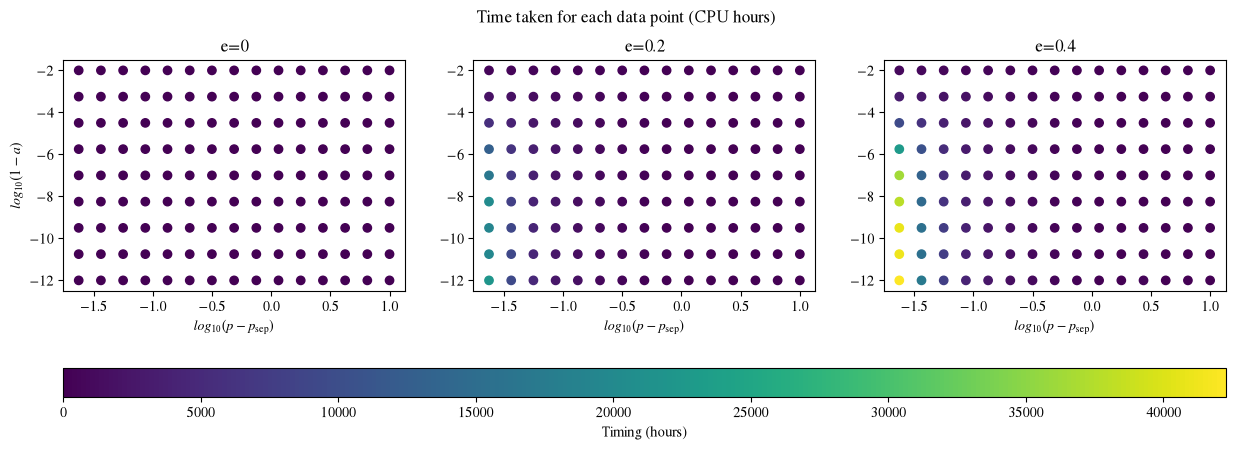

In [17]:
js = [0,4,8]
es=  [0,0.2,0.4]
aa = np.min(timing_arr[:,:,:])
bb = np.max(timing_arr[:,:,:])

norm = mcolors.Normalize(vmin=aa, vmax=bb)
colorizer = mcolorizer.Colorizer(norm=norm)


fig, ax = plt.subplots(1,3,figsize = (15,5))
for i,j in enumerate(js):

    E = e_arr[:,j,:]
    P= p_arr[:,j,:]   #0 = a=0.99, 9 = a=1-10**-12
    A = a_arr[:,j,:]
    X= np.ones_like(P)

    Z= timing_arr[:,j,:]

    PSEP = get_separatrix(a_arr.flatten(),e_arr.flatten(),np.ones_like(e_arr).flatten())
    PSEP = PSEP.reshape(15,9,9)[:,j,:]

    cf1 = ax[i].scatter(np.log10(P - PSEP),np.log10(1-A),c=Z, cmap="viridis",vmin=aa,vmax=bb)
    ax[i].set_title(f"e={es[i]}")


ax[0].set_ylabel(r"$log_{10}(1-a)$")
ax[0].set_xlabel(r"$log_{10}(p-p_{\text{sep}})$")
ax[1].set_xlabel(r"$log_{10}(p-p_{\text{sep}})$")
ax[2].set_xlabel(r"$log_{10}(p-p_{\text{sep}})$")

plt.suptitle(rf"Time taken for each data point (CPU hours)")
fig.colorbar(cf1, ax=ax, label=r"Timing (hours)",
                pad = 0.2,orientation = "horizontal", fraction=0.2, aspect =40/1,)
                 # ticks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16])
plt.show()
fig.savefig(f"Timing.png", dpi=300, bbox_inches="tight")

/tmp/ipykernel_5867/3515825234.py:21: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 1 Axes> than <Figure size 1500x500 with 7 Axes> which fig.colorbar is called on.
  fig.colorbar(cf1, ax=ax, label=r"Timing (hours)",


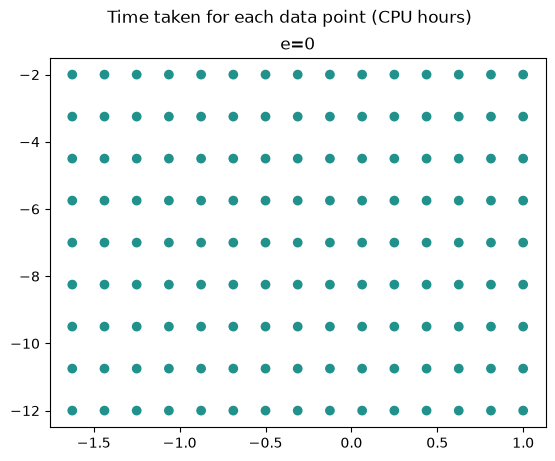

In [50]:
j=0
i=0


E = e_arr[:,j,:]
P= p_arr[:,j,:]   #0 = a=0.99, 9 = a=1-10**-12
A = a_arr[:,j,:]
X= np.ones_like(P)

Z= timing_arr[:,j,:]/3600

PSEP = get_separatrix(a_arr.flatten(),e_arr.flatten(),np.ones_like(e_arr).flatten())
PSEP = PSEP.reshape(15,9,9)[:,j,:]

cf1 = plt.scatter(np.log10(P - PSEP),np.log10(1-A),c=Z, cmap="viridis")
plt.title(f"e={es[i]}")



plt.suptitle(rf"Time taken for each data point (CPU hours)")
fig.colorbar(cf1, ax=ax, label=r"Timing (hours)",
                pad = 0.1,orientation = "horizontal", fraction=0.2, aspect =40/1,
                  ticks=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16])
plt.show()
#fig.savefig(f"contourplot_e_vs_p_n={n}_compare_with_few_ELQ.png", dpi=300, bbox_inches="tight")